# 4. Análisis univariado

Se mira cada variable por separado: primero la variable objetivo y luego las 10 predictoras.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from utils import *

set_style()
np.random.seed(SEED)
df = load_data()

## 4.1 Variable objetivo

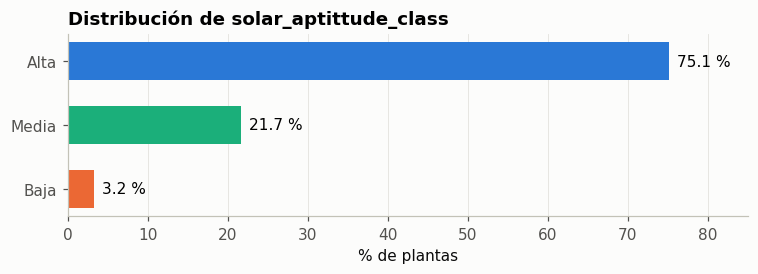

In [2]:
pct = df[TARGET].value_counts(normalize=True)[CLASS_ORDER] * 100
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(CLASS_ORDER, pct.values, height=0.6, color=[CLASS_COLORS[k] for k in CLASS_ORDER])
for y, v in enumerate(pct.values):
    ax.text(v + 1, y, f"{v:.1f} %", va="center")
ax.set_xlim(0, 85); ax.set_xlabel("% de plantas")
ax.set_title("Distribución de solar_aptittude_class")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

El desbalance es severo: **75.1 % Alta, 21.7 % Media y 3.2 % Baja** (1 892 plantas). Hay que evaluar con **F1 macro y recall por clase**.

## 4.2 Predictoras

### Histogramas

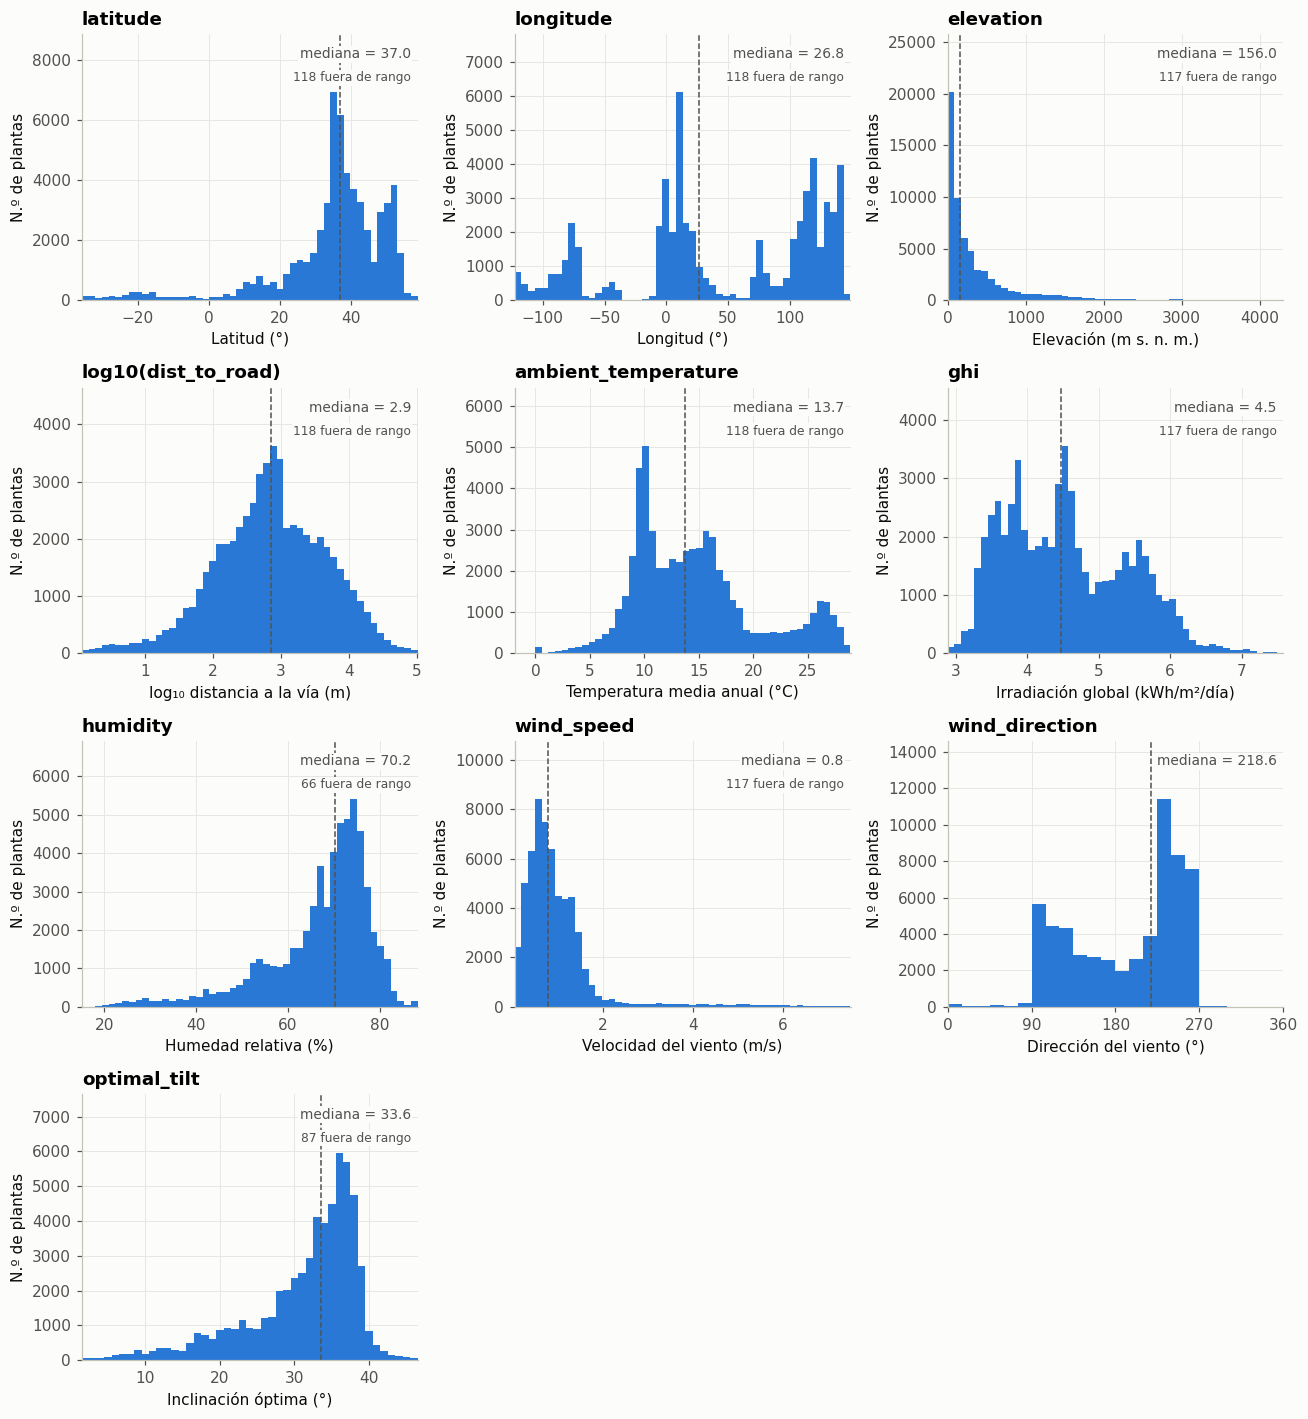

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(12, 13))
for ax, col in zip(axes.flat, NUMERIC):
    data = df[col].dropna()
    title, xlabel = col, AXIS_LABELS[col]
    if col == "dist_to_road":
        data = np.log10(data + 1)
        title, xlabel = f"log10({col})", "log₁₀ distancia a la vía (m)"
    if col == "wind_direction":
        lo, hi = 0, 360
    else:
        lo, hi = data.quantile([0.001, 0.999])
    inside = data.between(lo, hi)
    if col == "wind_direction":
        bins = np.arange(0, 361, 15)
    elif col == "optimal_tilt":
        bins = np.arange(np.floor(lo) - 0.5, np.ceil(hi) + 1)
    else:
        bins = np.linspace(lo, hi, 51)
    ax.hist(data[inside], bins=bins, color=CLASS_COLORS["Alta"])
    ax.set_ylim(0, ax.get_ylim()[1] * 1.22)
    med = data.median()
    ax.axvline(med, color=NEUTRAL, ls="--", lw=1)
    ax.text(0.98, 0.95, f"mediana = {med:.1f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color=NEUTRAL,
            bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1))
    n_out = (~inside).sum()
    if n_out:
        ax.text(0.98, 0.86, f"{n_out} fuera de rango", transform=ax.transAxes,
                ha="right", va="top", fontsize=8, color=NEUTRAL,
                bbox=dict(facecolor=SURFACE, edgecolor="none", pad=1))
    if col == "wind_direction":
        ax.set_xticks(range(0, 361, 90))
    ax.set_xlim(bins[0], bins[-1])
    ax.set_title(title)
    ax.set_xlabel(xlabel); ax.set_ylabel("N.º de plantas")
for ax in axes.flat[len(NUMERIC):]:
    ax.remove()
plt.tight_layout(); plt.show()

- `elevation` y `wind_speed` se amontonan cerca de cero y tienen una cola larga a la derecha: la mayoría de plantas está en sitios bajos y con poco viento.
- `dist_to_road` solo se puede leer en escala logarítmica.
- `longitude` tiene tres picos, que corresponden a América, Europa y Asia.
- `latitude` se concentra en el hemisferio norte; solo el 4.6 % de las plantas está al sur del ecuador.
- `optimal_tilt` se concentra entre 28° y 37° (mediana 33.6°), con una cola hacia 0° de las plantas cercanas al ecuador.
- `humidity` se carga hacia valores altos (70 % la mediana), y `ghi` y `ambient_temperature` tienen varios picos, reflejo de los distintos climas.
- `wind_direction` tiene dos picos: vientos del este-sureste y del suroeste.